
Running Hyperparameter Tuning...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Optimizer=adam | LR=0.01   | Batch=16 | Layers=1 | Activation=relu  | Validation Accuracy=0.9825
Optimizer=sgd  | LR=0.01   | Batch=16 | Layers=1 | Activation=relu  | Validation Accuracy=0.9561
Optimizer=adam | LR=0.01   | Batch=16 | Layers=1 | Activation=tanh  | Validation Accuracy=0.9912
Optimizer=sgd  | LR=0.01   | Batch=16 | Layers=1 | Activation=tanh  | Validation Accuracy=0.9737
Optimizer=adam | LR=0.01   | Batch=16 | Layers=2 | Activation=relu  | Validation Accuracy=0.9825
Optimizer=sgd  | LR=0.01   | Batch=16 | Layers=2 | Activation=relu  | Validation Accuracy=0.9649
Optimizer=adam | LR=0.01   | Batch=16 | Layers=2 | Activation=tanh  | Validation Accuracy=0.9912
Optimizer=sgd  | LR=0.01   | Batch=16 | Layers=2 | Activation=tanh  | Validation Accuracy=0.9825
Optimizer=adam | LR=0.01   | Batch=32 | Layers=1 | Activation=relu  | Validation Accuracy=0.9825
Optimizer=sgd  | LR=0.01   | Batch=32 | Layers=1 | Activation=relu  | Validation Accuracy=0.9561
Optimizer=adam | LR=0.01   | B

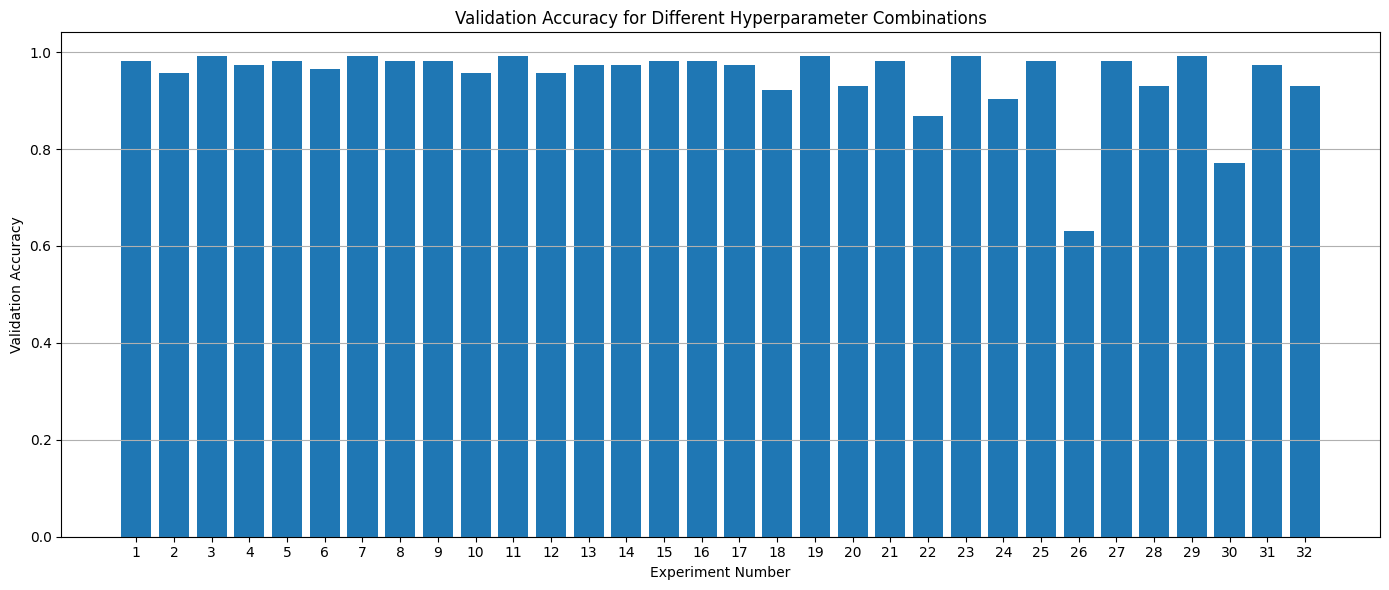

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9604 - loss: 0.1250 - val_accuracy: 0.9912 - val_loss: 0.0455
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9802 - loss: 0.0662 - val_accuracy: 0.9737 - val_loss: 0.0629
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9758 - loss: 0.0681 - val_accuracy: 0.9825 - val_loss: 0.0568
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9868 - loss: 0.0528 - val_accuracy: 0.9825 - val_loss: 0.0595
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9846 - loss: 0.0478 - val_accuracy: 0.9825 - val_loss: 0.0570
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9846 - loss: 0.0448 - val_accuracy: 0.9825 - val_loss: 0.0541
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9890 - loss: 0.0377 - val_accuracy: 0.9825 - val_loss: 0.0672
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9934 - loss: 0.0288 - val_accuracy: 0.9737 - val_loss: 0.0662
E

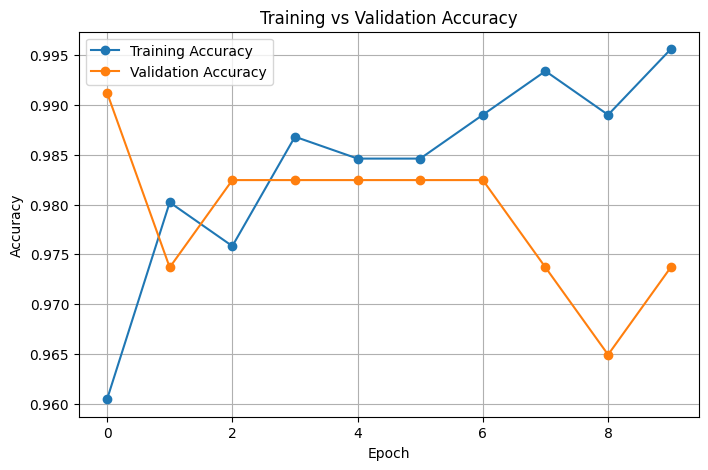

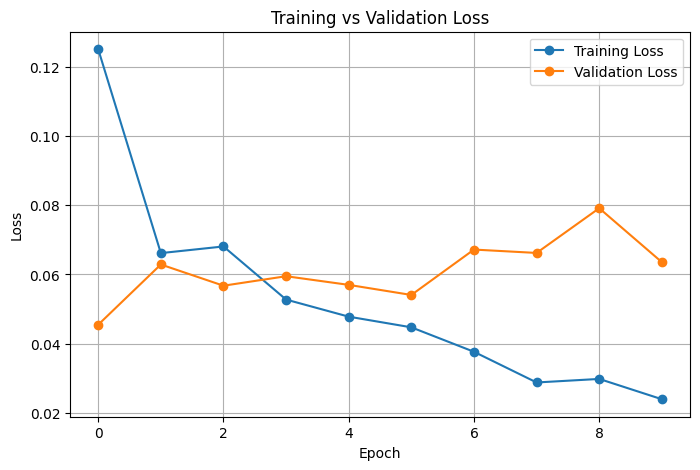



FINAL MODEL PERFORMANCE
Final Test Accuracy : 0.9737
Final Test Loss     : 0.0636


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# SHLOK VIJ 23070521143
# Practical 5:
# Hyperparameter Tuning and Model Optimization
# ----------------------------

# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Data Preprocessing
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Hyperparameters
learning_rates = [0.01, 0.001]
batch_sizes = [16, 32]
hidden_layers = [1, 2]
activations = ["relu", "tanh"]
optimizers = ["adam", "sgd"]

best_accuracy = 0
best_parameters = None
results = []

print("\nRunning Hyperparameter Tuning...\n")

# Hyperparameter Tuning
for lr in learning_rates:
    for batch in batch_sizes:
        for layers in hidden_layers:
            for activation in activations:
                for opt in optimizers:

                    model = Sequential()

                    model.add(Dense(
                        64,
                        activation=activation,
                        input_shape=(30,)
                    ))

                    for i in range(layers - 1):
                        model.add(Dense(
                            64,
                            activation=activation
                        ))

                    model.add(Dense(
                        1,
                        activation="sigmoid"
                    ))

                    if opt == "adam":
                        optimizer = tf.keras.optimizers.Adam(
                            learning_rate=lr
                        )
                    else:
                        optimizer = tf.keras.optimizers.SGD(
                            learning_rate=lr
                        )

                    model.compile(
                        optimizer=optimizer,
                        loss="binary_crossentropy",
                        metrics=["accuracy"]
                    )

                    history = model.fit(
                        X_train,
                        y_train,
                        epochs=10,
                        batch_size=batch,
                        validation_data=(X_test, y_test),
                        verbose=0
                    )

                    val_accuracy = max(history.history["val_accuracy"])

                    print(
                        f"Optimizer={opt:4} | "
                        f"LR={lr:<6} | "
                        f"Batch={batch:<2} | "
                        f"Layers={layers} | "
                        f"Activation={activation:<5} | "
                        f"Validation Accuracy={val_accuracy:.4f}"
                    )

                    results.append({
                        "Optimizer": opt,
                        "Learning Rate": lr,
                        "Batch Size": batch,
                        "Hidden Layers": layers,
                        "Activation": activation,
                        "Validation Accuracy": val_accuracy
                    })

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_parameters = (
                            opt,
                            lr,
                            batch,
                            layers,
                            activation
                        )

# ----------------------------
# Results Table
# ----------------------------

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("ALL HYPERPARAMETER COMBINATIONS")
print("=" * 80)
print(results_df)

# ----------------------------
# Best Hyperparameters
# ----------------------------

print("\n")
print("=" * 80)
print("SHLOK VIJ 23070521143")
print("=" * 80)

print("\nBest Hyperparameters")
print("------------------------------")
print("Optimizer      :", best_parameters[0])
print("Learning Rate  :", best_parameters[1])
print("Batch Size     :", best_parameters[2])
print("Hidden Layers  :", best_parameters[3])
print("Activation     :", best_parameters[4])
print("Best Validation Accuracy :", round(best_accuracy, 4))

# ----------------------------
# Graph 1
# Validation Accuracy Comparison
# ----------------------------

plt.figure(figsize=(14,6))

labels = []

for i in range(len(results_df)):
    labels.append(str(i+1))

plt.bar(labels, results_df["Validation Accuracy"])

plt.xlabel("Experiment Number")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Hyperparameter Combinations")

plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------
# Train Best Model
# ----------------------------

best_model = Sequential()

best_model.add(Dense(
    64,
    activation=best_parameters[4],
    input_shape=(30,)
))

for i in range(best_parameters[3]-1):
    best_model.add(Dense(
        64,
        activation=best_parameters[4]
    ))

best_model.add(Dense(
    1,
    activation="sigmoid"
))

if best_parameters[0] == "adam":
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=best_parameters[1]
    )
else:
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=best_parameters[1]
    )

best_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = best_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=best_parameters[2],
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# Graph 2
# Accuracy vs Epochs
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ----------------------------
# Graph 3
# Loss vs Epochs
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# ----------------------------
# Final Evaluation
# ----------------------------

loss, accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n")
print("=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)
print("Final Test Accuracy :", round(accuracy, 4))
print("Final Test Loss     :", round(loss, 4))